In [1]:
using DrWatson
@quickactivate "."
#using Pkg; Pkg.instantiate()

In [2]:
using DataFrames, DataFramesMeta, CSV 
using StatsPlots, Plots.Measures
default(leg = false)
theme(:default)

using EcotoxSystems, AmphiDEB
include(srcdir("utils.jl"));

using Revise

const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG_TKTDFIT = "Discoglossus_Flupyradifurone"
const SAVETAG = "Discoglossus_BdJEL423"

using Revise
includet(scriptsdir("ModelAnalysis_PathogenFlupyradifurone_CombinedEffects.jl"))

In [3]:
using Pkg
Pkg.status("AmphiDEB") # show version of AmphiDEB used

Status `C:\Users\shansul\Documents\AmphiDEBResearch\TKTD\Project.toml`
  [eee04faf] AmphiDEB v0.3.3 `https://github.com/simonhansul/amphideb.git#main`


In [4]:
Pkg.status("EcotoxSystems") # show version of EcotoxSystems used

Status `C:\Users\shansul\Documents\AmphiDEBResearch\TKTD\Project.toml`
  [a070e96f] EcotoxSystems v0.2.3 `https://github.com/simonhansul/ecotoxsystems.jl#main`


In [5]:
f = setup_simulations_combinedeffects("M");

┌ Info: Overwriting default values of String31["spc.Z", "spc.dI_max_lrv", "spc.k_M_emb", "spc.eta_AS_emb", "spc.H_j1", "spc.gamma", "spc.k_J_emb", "spc.kappa_emb", "spc.watercontent_larvae", "spc.watercontent_juveniles", "spc.time_since_birth"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch\TKTD\scripts\ModelAnalysis_PathogenFlupyradifurone_CombinedEffects.jl:209
┌ Info: Overwriting default values of String15["spc.dI_max_juv", "spc.eta_AS_juv", "spc.H_p", "spc.k_J_juv", "spc.eta_AR"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch\TKTD\scripts\ModelAnalysis_PathogenFlupyradifurone_CombinedEffects.jl:218
┌ Info: Overwriting default values of String15["spc.KD[1,1]", "spc.E[1,1]", "spc.B[1,1]"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch\TKTD\scripts\ModelAnalysis_PathogenFlupyradifurone_CombinedEffects.jl:231
┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase C:\Users\shansul\.ju

In [6]:
sim = vcat([f.simulator(mode.(f.prior.dists); return_raw = true) for _ in 1:10]...);

In [7]:
f.defaultparams.spc.KD

1×7 reshape(view(::Vector{Any}, 57:63), 1, 7) with eltype Any:
 0.970382  0.0  0.0  0.0  0.0  0.0  0.0

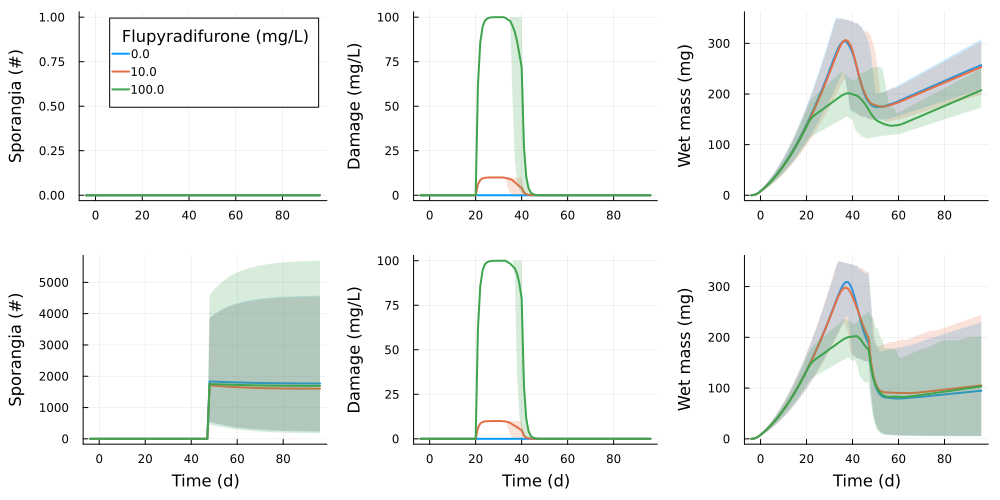

In [9]:
plt_noBD = @df @subset(sim, :treatment_bd .== "uninfected") plot(
    groupedlineplot(
        :t_exp, :P_S, :treatment_id, 
        leg = true, label = hcat(unique(:C_W_1)...), legendtitle = "Flupyradifurone (mg/L)",
        #palette = palette([:steelblue, :magenta, :darkgreen], 5)
        fillalpha = .2, lw = 2,
        ylabel = "Sporangia (#)"
    ), 
    groupedlineplot(
        :t_exp, :D_j_1_1, :treatment_id, 
        leg = false,
        legendtitle = "treatment",
        #palette = palette([:steelblue, :magenta, :darkgreen], 5),
        ylabel = "Damage (mg/L)",
        fillalpha = .2, lw = 2
    ), 
    groupedlineplot(
        :t_exp, :wetmass_mg, :treatment_id, 
        label = hcat(unique(:treatment_id)...), leg = false,
        legendtitle = "treatment",       
        fillalpha = .2, lw = 2, 
        ylabel = "Wet mass (mg)"
    ),


    layout = (1,3), 
    #title = ["Host growth" "Chemical damage" "Sporangia"]
)

plt_BD = @df @subset(sim, :treatment_bd .== "JEL423") plot(
    groupedlineplot(
        :t_exp, :P_S, :treatment_id, 
        leg = false,
        xlabel = "Time (d)",
        legendtitle = "treatment",
        #palette = palette([:steelblue, :magenta, :darkgreen], 5)
        fillalpha = .2, lw = 2,
        ylabel = "Sporangia (#)"
    ), 
    groupedlineplot(
        :t_exp, :D_j_1_1, :treatment_id, 
        leg = false,
        xlabel = "Time (d)",
        legendtitle = "treatment",
        #palette = palette([:steelblue, :magenta, :darkgreen], 5)
        fillalpha = .2, lw = 2,
        ylabel = "Damage (mg/L)",
    ), 
    groupedlineplot(
        :t_exp, :wetmass_mg, :treatment_id, 
        leg = false,
        xlabel = "Time (d)",
        legendtitle = "treatment", 
        fillalpha = .2, lw = 2,
        ylabel = "Wet mass (mg)"
        #palette = palette([:steelblue, :magenta, :darkgreen], 5)
    ),

    layout = (1,3)
)

plt = plot(
    plt_noBD,
    plt_BD,
    layout = (2,1), 
    lw = 2, 
    size = (1000,500), 
    leftmargin = 5mm, bottommargin = 5mm
)

savefig(plot(plt, dpi = 400), plotsdir("Projection_Flupyradifurone_BdJEL423.png"))
plt

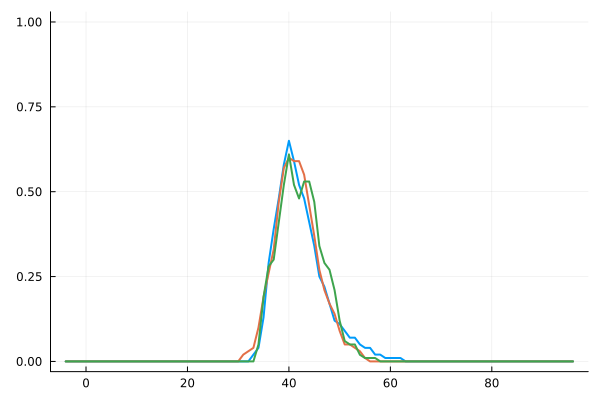

GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine INQ_TEXT
GKS: String is too long in routine TEXT


In [8]:
@df @subset(sim, :treatment_bd .== "uninfected") plot(
    groupedlineplot(
        :t_exp, :metamorph, :treatment_id, 
        label = hcat(unique(:treatment_id)...), leg = false,
        legendtitle = "treatment",       
        fillalpha = 0., lw = 2, 
        ylabel = :metamorph
    ))

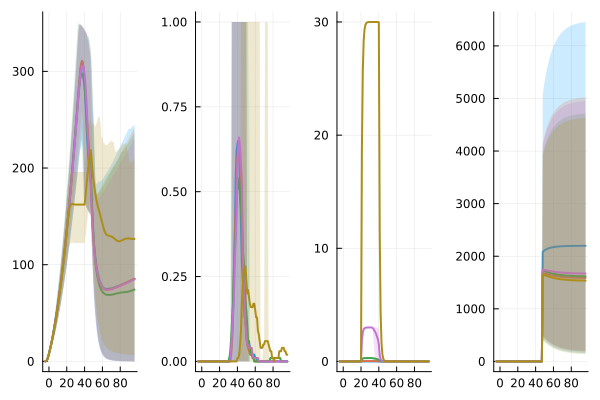

In [15]:

begin 
    plt_noBD = @df @subset(sim, :treatment_bd .== "uninfected") plot(
        groupedlineplot(
            :t_exp, :wetmass_mg, :treatment_id, 
            label = hcat(unique(:treatment_id)...), leg = :bottomright,
            legendtitle = "treatment",       fillalpha = .2, lw = 2
        ),
        groupedlineplot(
            :t_exp, :metamorph, :treatment_id, 
            leg = false,
            legendtitle = "treatment",
            fillalpha = .2, lw = 2
        ),
        groupedlineplot(
            :t_exp, :D_j_1_2, :treatment_id, 
            leg = false,
            legendtitle = "treatment",
            #palette = palette([:steelblue, :magenta, :darkgreen], 5)
            fillalpha = .2, lw = 2
        ), 
        groupedlineplot(
            :t_exp, :P_S, :treatment_id, 
            leg = false,
            legendtitle = "treatment",
            #palette = palette([:steelblue, :magenta, :darkgreen], 5)
            fillalpha = .2, lw = 2,
        ), 
        layout = (1,4)
    )

    plt_BD = @df @subset(sim, :treatment_bd .== "JEL423") plot(
        groupedlineplot(
            :t_exp, :wetmass_mg, :treatment_id, 
            leg = false,
            legendtitle = "treatment", 
            fillalpha = .2, lw = 2
            #palette = palette([:steelblue, :magenta, :darkgreen], 5)
        ),
        groupedlineplot(
            :t_exp, :metamorph, :treatment_id, 
            leg = false,
            legendtitle = "treatment",
            fillalpha = .2, lw = 2
            #palette = palette([:steelblue, :magenta, :darkgreen], 5)
        ),
        groupedlineplot(
            :t_exp, :D_j_1_2, :treatment_id, 
            leg = false,
            legendtitle = "treatment",
            #palette = palette([:steelblue, :magenta, :darkgreen], 5)
            fillalpha = .2, lw = 2,
        ), 
        groupedlineplot(
            :t_exp, :P_S, :treatment_id, 
            leg = false,
            legendtitle = "treatment",
            #palette = palette([:steelblue, :magenta, :darkgreen], 5)
            fillalpha = .2, lw = 2,
        ), 
        layout = (1,4)
    )
end


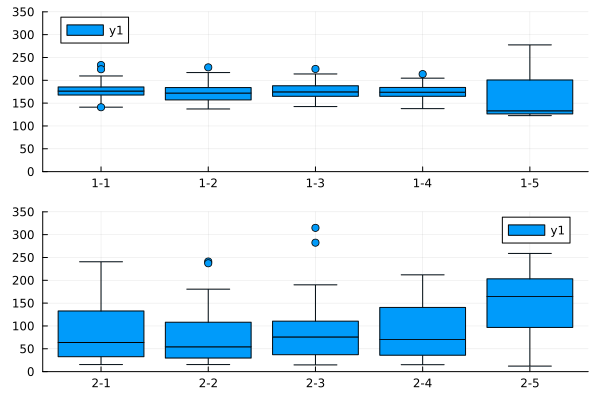

In [43]:
plt_noBd = @df @subset(sim, :treatment_bd .== "uninfected", :t .== 60) boxplot(
    :treatment_id, :wetmass_mg
)

plt_Bd = @df @subset(sim, :treatment_bd .== "JEL423", :t .== 60) boxplot(
    :treatment_id, :wetmass_mg
) 

plot(plt_noBd, plt_Bd, layout = (2,1), ylim = (0,350))